# Implement a Metropolis-Hasting Sampler

Do you remember it? it is a MCMC sampler and it is quite simple in logic.


Here is the algorithm (or you can check it from [doi:10.1093/mnras/stt2190](https://academic.oup.com/mnras/article/437/4/3918/1011939)):

1. Choose $\boldsymbol{x}_0 \in \Omega_\boldsymbol{\theta}$
2. For each step ($\boldsymbol{x}_i$) propose $\boldsymbol{x}_\text{trial}$ drawn from a symmetric distribution $q(\boldsymbol{x}_\text{trial}|\boldsymbol{x}_i)$ (a gaussian??)
3. Compute $k \equiv \text{min}[1, p(\boldsymbol{x}_\text{trial})/p(\boldsymbol{x}_i)]$ the new value is given by
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_i$ with probability $(1-k)$
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_\text{trial}$ with probability $k$
4. Iterate from (2) *until convergence*

# Material that we need

First of all the libraries:

In [1]:
import numpy as np
import random
from matplotlib import pyplot as plt

#package to check compatibility between function and parameters:
import inspect

In [2]:
#rng = np.random.default_rng(seed=666)
#to always have the same results move this in this cell

## Bayes Theorem:

Let me refresh you on this: an MCMC sampler uses the likelihood to sample the parameter space in search for a representation of the posterior:

$$P(\boldsymbol{\theta}|\boldsymbol{D}) \propto P(\boldsymbol{\theta}) \cdot \mathcal{L}_\boldsymbol{D}(\boldsymbol{\theta})$$ 

i.e. we drop the evidence as the intent is to move **walkers** around the parameter space and have a measure to test whether a new position is more likely than another.

If you remember from the statistics course, we do not use the likelihood directly but its logarithm (because it is more stable and because reasons).

But before looking on that, let's generate a dataset:

In [3]:
# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

In [4]:
# Generate some synthetic data from the model.

rng = np.random.default_rng(seed=666)

N = 50
xobs = np.sort(10 * rng.normal(size=N))

yerr = 0.1 + .5 * rng.normal(size=N)
yobs = m_true * xobs + b_true
yobs += np.abs(f_true * yobs) * rng.standard_normal(size=N)
yobs += yerr * rng.standard_normal(size=N)

yerr = np.abs(yerr)

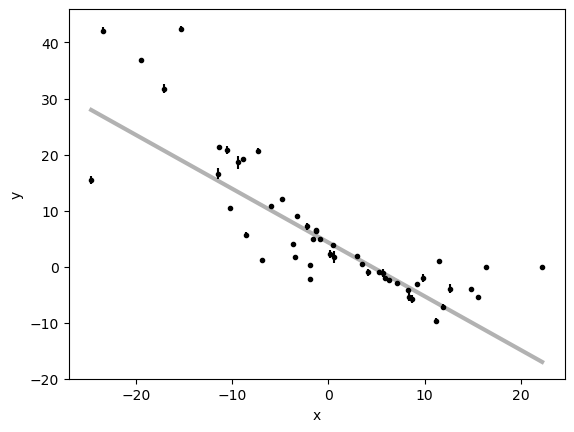

In [5]:
fig, ax = plt.subplots(1,1)

_ = ax.errorbar(xobs, yobs, yerr=yerr, fmt=".k", capsize=0)
#initial VALUES: X0:
x0 = np.linspace(xobs.min(), xobs.max(), 500)
#PLOTTING:
_ = ax.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
_ = ax.set(xlabel='x', ylabel='y')

## LogLikelihood and Prior

I feel particularly kind today therefore you will not have to implement the log-likelihood and log-prior yourself, do not get used to it.

In [6]:
def log_likelihood(theta, xx, yy, ee):
    #theta is the parameters
    #xx is the x data
    #yy is the y data
    #ee is the error on y
    m, b, log_f = theta
    model = m * xx + b
    sigma2 = ee**2 + model**2 * np.exp(2 * log_f)
    #x has no error
    return -0.5 * np.sum((yy - model) ** 2 / sigma2 + np.log(sigma2))

In [7]:
prior = [
    [-2.0,0.0],
    [2.0,6.0],
    [-4.0, 4.0]
]

In [8]:
def log_prior(theta, prior):
    m, b, log_f = theta
    mlim, blim, flim = prior
    if mlim[0] < m < mlim[1] and blim[0] < b < blim[1] and flim[0] < log_f < flim[1]:
        return 0.0
    return -np.inf

In [9]:
#posterior implementation: post = prior * likelihood
#in logarithm: prior + likelihood
#prior is the interval

def log_probability(theta, xx, yy, ee, prior):
    lp = log_prior(theta, prior)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, xx, yy, ee)

## The actual assignment

I want you to implement the algorithm detailed at the beginning of this notebook. Desiderata:

* I would like to have a class which implements the sampler, stores the positions visited by the walkers and whether a position has been accepted or not.
* The class should implement the best practices we have seen in class (e.g. implement a `__str__` dunder method for printing)
* the class should be documented
* the first thing an class instance method should do is to check whether the attributes that have been passed by the user (you are the user in this case) have the correct properties (raise an `AttributeError` if not)

**Hints:**
* **test** **test** **test** **test** **test** **test** every step, you are in a jupyter notebook, open a new cell and test each functionality before inserting it into the class implementation
* I have provided at the end the code snippet to plot the marginalized posterior, nonetheless, I can already tell you that it should be gaussian (as the dataset is gaussian), thus the **mean** and **standard deviation** are good estimators of the posterior.
* you can try to implement it with **a single walker for starting**, doing it with multiple workers can be an extension

**Bonus:**
* If you feel particularly productive, also wrap everything into a module or a package.

**The algorithm again here**
[doi:10.1093/mnras/stt2190](https://academic.oup.com/mnras/article/437/4/3918/1011939):

1. Choose $\boldsymbol{x}_0 \in \Omega_\boldsymbol{\theta}$
2. For each step ($\boldsymbol{x}_i$) propose $\boldsymbol{x}_\text{trial}$ drawn from a symmetric distribution $q(\boldsymbol{x}_\text{trial}|\boldsymbol{x}_i)$ (a gaussian??)
3. Compute $k \equiv \text{min}[1, p(\boldsymbol{x}_\text{trial})/p(\boldsymbol{x}_i)]$ the new value is given by
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_i$ with probability $(1-k)$
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_\text{trial}$ with probability $k$
4. Iterate from (2) *until convergence*

## My solution

In [10]:
class Mcmc_sampler() :
    """
        Class that represents an MCMC sampler, using the Metropolis Hastings algorithm to reconstruct a posterior.
        Being a sampler, it will contain:
        -method to extract and accept points
        -attribute that represents the accepted (and rejected) points (steps)
        -attribute that represents the list of their probabilities 
    """
    
    #Initializing the sampler: non-modifiable method that initializes the attributes of the class
    def __init__ ( 
            self, 
            nwalkers, #number of walkers, for this implementation, will be nwalkers = 1
            logprob, #the log_probability function defined above
            ndim, #number of free parameters (3)
            lp_args = tuple() #this argument stores the inputs of the logprob function
        ) :
        
        # check here that the inputs are correct:
        if (not isinstance( nwalkers, int )) or (nwalkers < 1):
            raise AttributeError('nwalkers should be a positive integer')
        self.nwalkers = nwalkers
        
        #check that logprob is a function by checking it behaves as a function (can be called)
        if not callable(logprob):
            raise AttributeError('logprobl must be a callable function')
        self.logprob = logprob
        
        #check that the number of dimensions is 3 (exactly 3, here)
        if (ndim <= 0) or (ndim !=3):
            raise AttributeError('ndim should be positive number, and equal to 3 as long as other logprobs will not be implemented')
        self.ndim = ndim
        
        #Standard way to check if the addiitonal parameters are compatible with the function: I want to check if the parameters 
        #given by the user as lp_args, are equal to the parameters that the function logprob wants.
        #inspect.signature calls the function and checks the parameters in the definition of logprob
        sig = inspect.signature(logprob) #checks the parameters in the definition of logprob

        #then tries assigning (binding) the content of lp_args to the function. bind only checks the number,
        #but not the type! So it works even with numbers and if you want to check the type, you must do it a side
        #I tried to check the type too but the check never failed
        try:
            sig.bind(None, *lp_args) #if an error is raised here due to the incorrect type, read the error e
            #and tell it to the user
        except TypeError as e:
            raise ValueError(f'lp_args is incompatible with logprob: {e}')
        self.lp_args = lp_args
        
        # initialize the class instance attributes
        self.steps = [] #list of steps, both accepted and not
        self.logprobs = [] #list of probabilities of the accepted points
        self.accepted = 0 #number of accepted points
        self.rejected = 0 #number of rejected points
        
    def theta0_extraction(self, xdata:array, ydata:array, yerrors:array, priors:list)->list:

        """
            Function to extract the starting point for the Metropolis Hasting algorithm. The first point is a list of
            three floats since theta = 3 parameters.
            Parameters:
            ----------
                        -xdata:array. Data on x (will be needed to compute the probability of the first point
                               through the product of likelihood and prior)
                        -ydata:array. Data on y (needed for probability computation)
                        -yerrors:array. Errors on y (needed for probability computation)
                        -priors:list of lists. Each list must be two floats. Each list represents one prior interval.
            
            Returns:
            --------
                        theta0:list of floats, read as array. The first point extracted. It gets appended into self.steps as
                               the first element of the chain of steps
        """
        
        theta0 = [] #list where to append the result
        for elem in priors:
            #prior is a list of intervals. of each interval read the first element and set it to be the 
            lower = elem[0]
            higher = elem[1]
            theta0.append(random.uniform(lower, higher)) #from the prior, uniformly #number one for every element
        print('Extracted first theta0')
        
        #first step
        self.steps.append(np.asarray(theta0)) #converted into array to have the same type 
        self.logprobs.append(float(log_probability(theta0, xdata, ydata, yerrors, priors)))
        
        return np.asarray(theta0)
      
    def next_point_proposal(self)->array:
        '''
            Function to extract the new point theta (three floats) given the initial point theta0,
            extracting each point from a symmetric normal distribution centered on theta0 and with fixed sigma
            
            Returns: theta1:array. Array of the three new proposals (one for each parameter)
        '''
        #extract three points, one for each theta0, from three normal distributions, all with mean 0 but then
        #shifted of theta0 (so it is as if the mean was equal to theta0) and sigma = 0.05 for all distributions
        #The sigma could be different among distribution but like this is is inline and more compactù
        theta1 = self.steps[-1] + np.random.normal(0, 0.05, size=3)
        
        return theta1
    
    def select_point(self, theta1:array, xdata:array, ydata:array, errors:array, prior:list)->bool:
        '''
            Function to select which point will be the next step in the chain. Selects the last point in the
            chain (self.steps[-1]) that corresponds to the current status of the chain. Then compares the probability
            of that step (called current step or this step) with the following steps's (proposed or next step) probability.
            It then accepts the current step with probability k, and the following step with probability 1-k. If the
            current step is accepted, then it is appended to self.steps, instead if the proposed step is accepted, the proposed
            step is appended to self.steps
            
            Parameters:
            -----------
                        theta1:array = Array of the successive step (computed in self.run from the current one)
                        xdata:array. Data on x (will be needed to compute the probability of the first point
                               through the product of likelihood and prior)
                        -ydata:array. Data on y (needed for probability computation)
                        -yerrors:array. Errors on y (needed for probability computation)
                        -prior:list of lists. Each list must be two floats. Each list represents one prior interval.
            Returns:
            --------
                        accepted:boolean. Whether the proposed step has been accepted or not in the chain
        '''

        #log probability value of the current step (theta0 for the first run, then the last element of self.steps)
        logpb_this_step = log_probability(self.steps[-1], xdata, ydata, errors, prior)

        #log probability value of the proposed next step. the proposed next step is obtained from the last element of self.steps
        #in the method self.run
        logpb_next_step = log_probability(theta1, xdata, ydata, errors, prior)

        #checking that the current step probability is not -infinity, since that value is out of the allowed region
        #for the posterior
        if (logpb_this_step != -np.inf):
            
            #compute the ratio of the two probabilities. since the logarithmic probabilities are logarithms, this equals
            #to taking the difference between the two logprobs
            log_ratio = logpb_next_step - logpb_this_step
            #convert back from logarithm to actual value
            ratio = np.exp(log_ratio)
            
            #compute the minimum between the ratio of probs and one:
            k = np.min([1., ratio])
            
            #extract a random number between 0 and 1
            u = np.random.rand()
            
            if u < k: #accept the proposed next point. The proposed step becomes the new new_step
                new_step = theta1
                new_prob = logpb_next_step
                self.accepted += 1
                accepted = True
            else: #reject the proposed next point. The current step becomes the new new_step.
                new_step = self.steps[-1]
                new_prob = logpb_this_step
                self.rejected += 1
                accepted = False
        
        #append either the current or the next step to the chain of steps
        self.steps.append(new_step)
        self.logprobs.append(float(new_prob)) #and its probability

        return accepted
    
    
    def run(self, nsteps:int, xdata:array, ydata:array, yerrors:array, priors:list)->float:
        """
            Function to run the sampler.
            
            Parameters:
            -----------
                        steps:integer. Number of steps for which the process is being repeated
                        xdata:array. Data on x (will be needed to compute the probability of the first point
                               through the product of likelihood and prior)
                        -ydata:array. Data on y (needed for probability computation)
                        -yerrors:array. Errors on y (needed for probability computation)
                        -priors:list of lists. Each list must be two floats. Each list represents one prior interval.
            Returns: 1
        """
        #consistency check: the number of steps must be greater than 1
        if nsteps <1:
            raise AttributeError('Number of steps should be integer greater than 1')
            
        else:
            theta0_chosen = self.theta0_extraction(xdata, ydata, yerrors, priors) #save theta 0 among the steps
            
            #extract nsteps theta1: for each step start from the previous sample.steps element (for i =1, sample.steps[-1] = theta0)
            for i in range(1, nsteps, 1):
                #the for starts from 1 because theta0 is always element 0
                theta1 = self.next_point_proposal()
                accepted = self.select_point(theta1, xdata, ydata, yerrors, priors)
            print('********************\n**************\nRun is over. Accepted number of points:', self.accepted)
            
        return 1
    
    def get_flat_chain(self, burnin=0, step=1):
        """
            Function to flatten the chains, which means to erase the steps that are not converging.
            Uses slicing to select just the points for which the chain converged: it keeps the sample.steps between burnin and the
            end, selecting one sample.steps element every step.

        Parameters:
        ----------
                      burnin:int. Number of initial samples to discard from the chain sample.steps. Default: 0
                      step:int. One value every step is kept. Called thinning factor

        Returns:
        -------
                      flattened:list. self.steps[burnin::step]
        """
        flattened = [] #burnin: avoid the first burnin elements, take elements every step
        flattened += self.steps[burnin::step]
        return flattened
    
    
    def acceptance_fraction(self):
        """
            Function to compute the acceptance fraction of the chain, so the number of accepted points with respect to
            the total number of proposed samples.
            Returns: frac:float = Fraction accepted/(accepted + rejected) = accepted/(total)
        """
        
        if (self.accepted ==0):
            raise AttributeError('Before computing the acceptance fraction, run the sampler with instance.run(args)')
            
        else:
            frac = self.accepted/(len(self.steps))
            print(self.accepted)
            print(len(self.steps))
            print("Acceptance fraction is %.1f%%" % (frac*10**2))
            
        return frac

### Tests

In [11]:
sampler = Mcmc_sampler(nwalkers = 1, logprob = log_probability, ndim = 3, lp_args = [xobs, yobs, yerr, prior])
print(sampler)

In [12]:
sampler.run(nsteps = 10000, xdata = xobs, ydata = yobs, yerrors = yerr, priors = prior)

Extracted first theta0
********************
**************
Run is over. Accepted number of points: 5863


1

In [13]:
sampler.acceptance_fraction()

5863
10000
Acceptance fraction is 58.6%


0.5863

In [14]:
outchain = np.asarray(sampler.get_flat_chain(10, 2))

### Plot of the chain

4995
4995


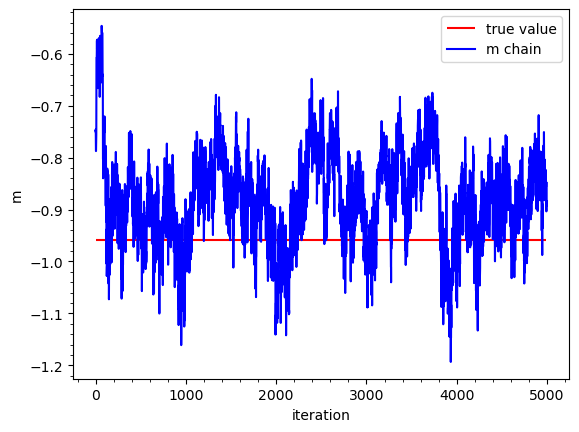

In [15]:
m = outchain[:,0]
print(len(m))
iteration = np.arange(len(outchain))
print(len(iteration))

#Plotting the m chain to see if something is wrong
plt.figure('m chain plot')
plt.hlines(m_true, xmin = min(iteration), xmax = max(iteration), colors = 'red', label = 'true value')
plt.plot(iteration, m, color = 'blue', label = 'm chain')
plt.legend(loc = 'best')
plt.minorticks_on()
plt.ylabel('m')
plt.xlabel('iteration')
plt.show()

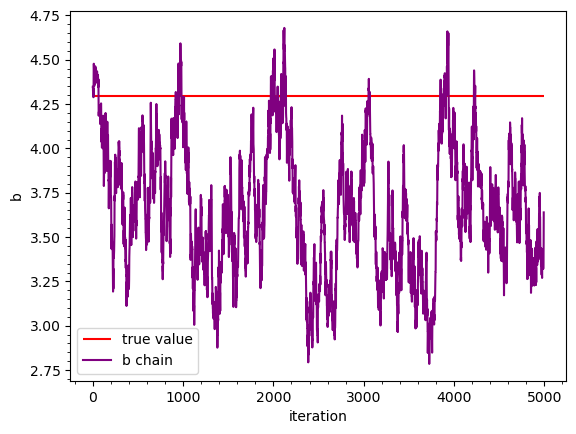

In [16]:
b = outchain[:,1]

#Plotting the m chain to see if something is wrong
plt.figure('b chain plot')
plt.hlines(b_true, xmin = min(iteration), xmax = max(iteration), colors = 'red', label = 'true value')
plt.plot(iteration, b, color = 'purple', label = 'b chain')
plt.legend(loc = 'best')
plt.minorticks_on()
plt.ylabel('b')
plt.xlabel('iteration')
plt.show()

#b does not converge much

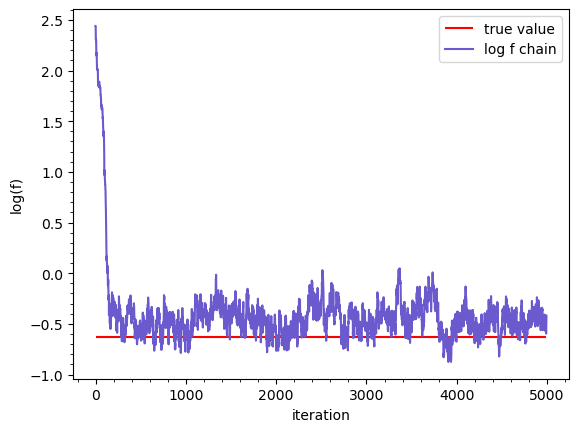

In [17]:
log_f = outchain[:,2]

#Plotting the m chain to see if something is wrong
plt.figure('log f chain plot')
plt.hlines(np.log(f_true), xmin = min(iteration), xmax = max(iteration), colors = 'red', label = 'true value')
plt.plot(iteration, log_f, color = 'slateblue', label = 'log f chain')
plt.legend(loc = 'best')
plt.ylabel('log(f)')
plt.xlabel('iteration')
plt.minorticks_on()
plt.show()

#log f converges

### Corner plot

In [18]:
import corner

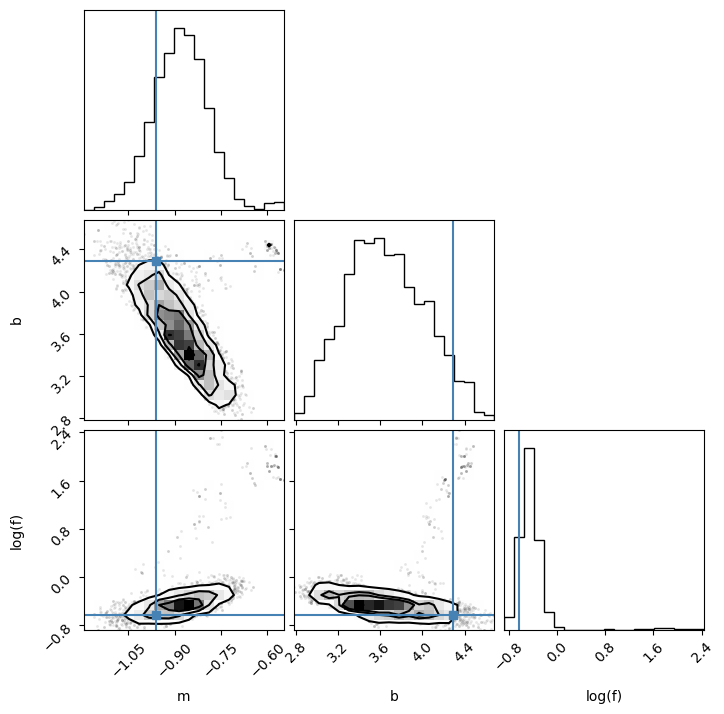

In [19]:
outchain = np.asarray(sampler.get_flat_chain(burnin = 10, step = 2))

fig = corner.corner(
    outchain, labels = ["m", "b", "log(f)"], truths = [m_true, b_true, np.log(f_true)]
)